# Caderno 03: A Bússola Eleitoral Interativa (VAA)

As *Voting Advice Applications* (VAA), como a Bússola Eleitoral holandesa ou o Wahl-O-Mat alemão, são ferramentas digitais que automatizam a lógica espacial para o eleitor em tempo real.

Neste caderno, implementamos a versão interativa da teoria apresentada no Caderno 02. Preencha os formulários e descubra o seu alinhamento individual.


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

In [2]:
partidos_data = {
    'Partido': ['PT', 'PL', 'NOVO', 'PDT'],
    'ideologia': ['Social-Democracia', 'Centrão/Fisiológico', 'Liberalismo Clássico', 'Trabalhismo'],
    'justificativa': ['Partido de massas com foco no estado de bem-estar social', 'Foco na governabilidade', 'Foco em desregulamentação e estado mínimo', 'Defesa da indústria nacional e do trabalhador'],
    'bloco_d_estatais': [2, 4, 5, 2],
    'bloco_d_tabelamento': [3, 2, 1, 3],
    'bloco_e_punitivismo': [2, 4, 3, 3],
    'bloco_e_educacao': [2, 4, 3, 2],
    'bloco_g_corrupcao': [2, 4, 5, 2],
    'bloco_g_pesquisa': [4, 2, 1, 5],
    'bloco_g_politica_externa': [4, 2, 1, 4]
}
df_partidos = pd.DataFrame(partidos_data).set_index('Partido')

politicos_data = {
    'Político': ['Lula', 'Flavio Bolsonaro', 'Romeu Zema', 'Ciro Gomes'],
    'ideologia': ['Pragmatismo Progressista', 'Direita Radical', 'Neoliberalismo', 'Nacional-Desenvolvimentismo'],
    'justificativa': ['Conciliação de classes e pautas sociais', 'Pauta de costumes conservadora e punitivismo', 'Livre mercado estrito e alianças de conveniência', 'Estado forte na economia e crítica ao rentismo'],
    'bloco_d_estatais': [1, 5, 5, 2],
    'bloco_d_tabelamento': [4, 1, 1, 3],
    'bloco_e_punitivismo': [2, 5, 4, 3],
    'bloco_e_educacao': [2, 5, 4, 2],
    'bloco_g_corrupcao': [1, 5, 5, 2],
    'bloco_g_pesquisa': [5, 1, 2, 5],
    'bloco_g_politica_externa': [5, 1, 2, 4]
}
df_politicos = pd.DataFrame(politicos_data).set_index('Político')
cols_opiniao = ['bloco_d_estatais', 'bloco_d_tabelamento', 'bloco_e_punitivismo', 'bloco_e_educacao', 'bloco_g_corrupcao', 'bloco_g_pesquisa', 'bloco_g_politica_externa']

In [3]:
# Interface (Widgets)
style = {'description_width': 'initial'}
nome_widget = widgets.Text(value='Eleitor', description='Nome:', style=style)
estatais_widget = widgets.IntSlider(value=3, min=1, max=5, description='Privatização de Estatais (1=Estado Forte, 5=Privatização Total):', style=style, layout=widgets.Layout(width='80%'))
tabelamento_widget = widgets.IntSlider(value=3, min=1, max=5, description='Controle de Preços (1=Livre Mercado, 5=Intervenção Estatal):', style=style, layout=widgets.Layout(width='80%'))
punitivismo_widget = widgets.IntSlider(value=3, min=1, max=5, description='Segurança Pública (1=Ressocialização, 5=Punição Severa):', style=style, layout=widgets.Layout(width='80%'))
educacao_widget = widgets.IntSlider(value=3, min=1, max=5, description='Educação (1=Progressista, 5=Conservadora):', style=style, layout=widgets.Layout(width='80%'))
corrupcao_widget = widgets.IntSlider(value=3, min=1, max=5, description='Corrupção (1=Sistêmica, 5=Punitiva):', style=style, layout=widgets.Layout(width='80%'))
pesquisa_widget = widgets.IntSlider(value=3, min=1, max=5, description='Pesquisa (1=Privada, 5=Estado):', style=style, layout=widgets.Layout(width='80%'))
politica_externa_widget = widgets.IntSlider(value=3, min=1, max=5, description='Pol. Externa (1=EUA/Ocid., 5=Sul Global):', style=style, layout=widgets.Layout(width='80%'))
rejeicao_widget = widgets.Dropdown(options=['Nenhum'] + list(df_politicos.index), value='Nenhum', description='Rejeição Absoluta:', style=style)
display(widgets.VBox([nome_widget, estatais_widget, tabelamento_widget, punitivismo_widget, educacao_widget, corrupcao_widget, pesquisa_widget, politica_externa_widget, rejeicao_widget]))

Execute a célula abaixo APÓS preencher os dados acima para ver seu cálculo interativo e mapa PCA.



🏆 Político Ideal: Ciro Gomes | Ideologia: Nacional-Desenvolvimentismo
🏛️ Partido Ideal: PT | Ideologia: Social-Democracia


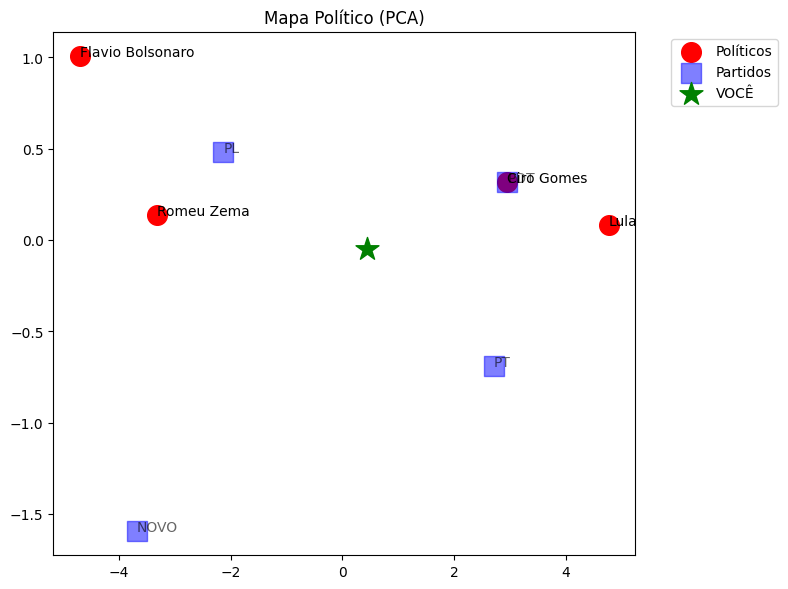

In [4]:
vetor_eleitor = np.array([[estatais_widget.value, tabelamento_widget.value, punitivismo_widget.value, educacao_widget.value, corrupcao_widget.value, pesquisa_widget.value, politica_externa_widget.value]])

dist_partidos = euclidean_distances(vetor_eleitor, df_partidos[cols_opiniao].values)[0]
dist_politicos = euclidean_distances(vetor_eleitor, df_politicos[cols_opiniao].values)[0]

res_partidos = pd.DataFrame({'Partido': df_partidos.index, 'Distancia': dist_partidos}).sort_values(by='Distancia').reset_index(drop=True)
res_politicos = pd.DataFrame({'Político': df_politicos.index, 'Distancia': dist_politicos})
res_politicos['Veto_Aplicado'] = res_politicos['Político'].apply(lambda x: True if x == rejeicao_widget.value else False)
res_politicos.loc[res_politicos['Veto_Aplicado'] == True, 'Distancia'] = np.inf
res_politicos = res_politicos.sort_values(by='Distancia').reset_index(drop=True)

cand_ideal = res_politicos.iloc[0]['Político']
part_ideal = res_partidos.iloc[0]['Partido']
print(f"\n🏆 Político Ideal: {cand_ideal} | Ideologia: {df_politicos.loc[cand_ideal, 'ideologia']}")
print(f"🏛️ Partido Ideal: {part_ideal} | Ideologia: {df_partidos.loc[part_ideal, 'ideologia']}")

# PCA Map
pca = PCA(n_components=2)
vetores_totais = np.vstack([df_politicos[cols_opiniao].values, df_partidos[cols_opiniao].values, vetor_eleitor])
proj = pca.fit_transform(vetores_totais)
plt.figure(figsize=(8,6))
plt.scatter(proj[:4, 0], proj[:4, 1], c='red', s=200, label='Políticos', marker='o')
plt.scatter(proj[4:8, 0], proj[4:8, 1], c='blue', s=200, label='Partidos', marker='s', alpha=0.5)
plt.scatter(proj[-1, 0], proj[-1, 1], c='green', s=300, label='VOCÊ', marker='*')
for i, txt in enumerate(df_politicos.index): plt.annotate(txt, (proj[i,0], proj[i,1]))
for i, txt in enumerate(df_partidos.index): plt.annotate(txt, (proj[i+4,0], proj[i+4,1]), alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Mapa Político (PCA)')
plt.tight_layout()
plt.show()